# mount the drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("Done loading libraries")

Done loading libraries


# Load the credit card dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')
# print("Shape:", df.shape)
# df.head(40)
res= df.loc[df['Class']==1]
print(res)

            Time        V1        V2        V3        V4        V5        V6  \
541        406.0 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545   
623        472.0 -3.043541 -3.157307  1.088463  2.288644  1.359805 -1.064823   
4920      4462.0 -2.303350  1.759247 -0.359745  2.330243 -0.821628 -0.075788   
6108      6986.0 -4.397974  1.358367 -2.592844  2.679787 -1.128131 -1.706536   
6329      7519.0  1.234235  3.019740 -4.304597  4.732795  3.624201 -1.357746   
...          ...       ...       ...       ...       ...       ...       ...   
279863  169142.0 -1.927883  1.125653 -4.518331  1.749293 -1.566487 -2.010494   
280143  169347.0  1.378559  1.289381 -5.004247  1.411850  0.442581 -1.326536   
280149  169351.0 -0.676143  1.126366 -2.213700  0.468308 -1.120541 -0.003346   
281144  169966.0 -3.113832  0.585864 -5.399730  1.817092 -0.840618 -2.943548   
281674  170348.0  1.991976  0.158476 -2.583441  0.408670  1.151147 -0.096695   

              V7        V8        V9  .

# Analyzing dataset, check for missing values, class imbalance and fraud percentage

In [ ]:
# Overview
print(df.info())
print("\n")

# Check for missing values
print("Missing values:\n", df.isnull().sum())
print("\n")

# Class distribution
print("Class distribution:\n", df['Class'].value_counts())
print("\n")

# Fraud percentage
fraud_pct = df['Class'].value_counts(normalize=True) * 100
print("Fraud percentage:\n", fraud_pct)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# Visualizing the fraud gap
simple bar graph to show the massive difference between normal and fraud transactions.

/tmp/ipykernel_1503/1803017246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['steelblue','red'])


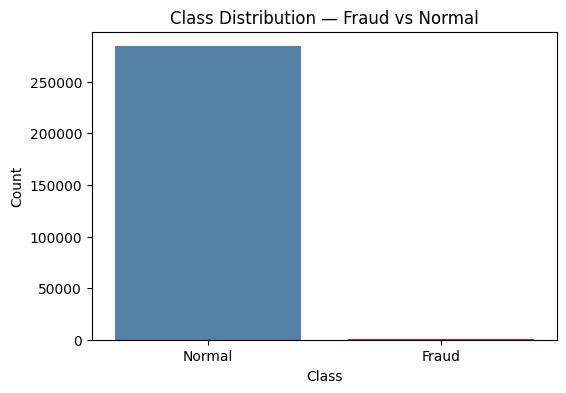

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['steelblue','red'])
plt.title('Class Distribution — Fraud vs Normal')
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.ylabel('Count')
plt.show()

#Scaling the Amount and Time Columns
The time and amount columns have much larger values than the rest of the features (V1 TO V8), which can confuse the model. This step shrinks them down to a similar scale so the model treats all inputs equally. We then delete the old, unscaled columns to keep the dataset clean.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_Time'] = scaler.fit_transform(df[['Time']])

# Drop original columns
df.drop(['Amount', 'Time'], axis=1, inplace=True)

print("Scaling done")
print(df.head())

Scaling done
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  scaled_Amount  

#Installing and Importing Imbalance Handling Tools
This step installs the imbalanced-learn library and prepares the tools needed to split the data and fix the fraud shortage. We use SMOTE to create synthetic fraud examples so the model has enough data to learn what fraud actually looks like.

In [ ]:
!pip install imbalanced-learn -q

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print("Imports done")

Imports done


# Separating Features from the Target
This step splits the data into two parts: X (all the transaction details the model will learn from) and y (the answer key that says whether a transaction was fraud or not). This is a standard prep step before feeding the data into any machine learning algorithm.

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Fraud cases:", y.sum())

X shape: (284807, 30)
y shape: (284807,)
Fraud cases: 492


#Splitting Data into Training and Testing Sets


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (227845, 30)
Test size: (56962, 30)


# Balancing the Data with SMOTE
Since there are so few fraud cases, the model might struggle to learn their patterns. This step uses SMOTE to create fake but realistic fraud examples for the training set. By making the number of fraud and normal cases equal, we give the model a much better chance of catching future fraud.

In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [ ]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay)



# Training the Random Forest Model
Random forest is like a team of many different decision trees working together to learn the fraud patterns. We use the balanced SMOTE data so the model becomes an expert at spotting both normal and suspicious transactions.

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train_sm, y_train_sm)
print("Random Forest trained")

Random Forest trained


#Generating Predictions with the Random Forest
This step uses the trained model to guess whether the transactions in the test set are fraud or normal. We also calculate the probability scores, which tell us how confident the model is in its fraud guesses this is super helpful later for fine-tuning the results.

In [ ]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Predictions done")

Predictions done


In [ ]:
print("RANDOM FOREST RESULTS")
print(classification_report(y_test, rf_pred,
      target_names=['Normal', 'Fraud']))
print("AUC-ROC Score:", round(roc_auc_score(y_test, rf_prob), 4))

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC Score: 0.9688



# Visualizing Model(HEAT MAP) Results with a Confusion Matrix
This heatmap shows exactly how well the model did. It counts how many times the model correctly identified fraud, how many times it missed it, and how many times it got false alarms (mistaking a normal transaction for fraud).

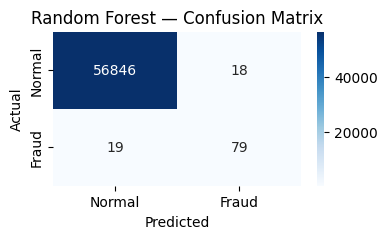

In [ ]:
plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Training the XGBoost Model
XGBoost is a powerful and fast algorithm that is often used for fraud detection. Like rf model, it learns from the balanced SMOTE data to find subtle, complex patterns that distinguish fraud from normal spending.

In [ ]:
xgb_model = XGBClassifier(n_estimators=100,
                           learning_rate=0.1,
                           max_depth=6,
                           random_state=42,
                           eval_metric='logloss',
                           n_jobs=-1)

xgb_model.fit(X_train_sm, y_train_sm)
print("XGBoost trained")

XGBoost trained


In [ ]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]


print("XGBOOST RESULTS")
print(classification_report(y_test, xgb_pred,
      target_names=['Normal', 'Fraud']))
print("AUC-ROC Score:", round(roc_auc_score(y_test, xgb_prob), 4))

XGBOOST RESULTS
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.35      0.87      0.49        98

    accuracy                           1.00     56962
   macro avg       0.67      0.93      0.75     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC Score: 0.976


In [ ]:
threshold = 0.6

xgb_pred_tuned = (xgb_prob >= threshold).astype(int)

print("XGBOOST TUNED RESULTS")
print(classification_report(y_test, xgb_pred_tuned,
      target_names=['Normal', 'Fraud']))
print("AUC-ROC Score:", round(roc_auc_score(y_test, xgb_prob), 4))

XGBOOST TUNED RESULTS
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.43      0.87      0.58        98

    accuracy                           1.00     56962
   macro avg       0.72      0.93      0.79     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC Score: 0.976


In [ ]:
for threshold in [0.6, 0.65, 0.7, 0.75, 0.8]:
    preds = (xgb_prob >= threshold).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = round(precision_score(y_test, preds), 2)
    r = round(recall_score(y_test, preds), 2)
    f = round(f1_score(y_test, preds), 2)
    print(f"Threshold {threshold} → Precision: {p} | Recall: {r} | F1: {f}")

Threshold 0.6 → Precision: 0.43 | Recall: 0.87 | F1: 0.58
Threshold 0.65 → Precision: 0.48 | Recall: 0.87 | F1: 0.62
Threshold 0.7 → Precision: 0.51 | Recall: 0.87 | F1: 0.64
Threshold 0.75 → Precision: 0.56 | Recall: 0.87 | F1: 0.68
Threshold 0.8 → Precision: 0.62 | Recall: 0.85 | F1: 0.72


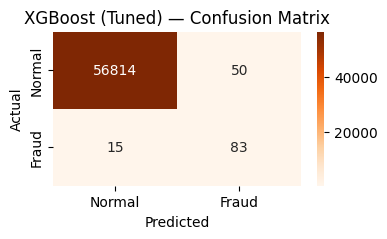

In [ ]:

xgb_final_pred = (xgb_prob >= 0.8).astype(int)

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test, xgb_final_pred),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('XGBoost (Tuned) — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Unsupervised Fraud Detection with Isolation Forest
Isolation forest model tries to find fraud by looking for transactions that are weird or isolated from the rest, without being told which ones were fraud beforehand. We set the contamination to match our 0.17% fraud rate to help it know how many outliers to look for.

In [ ]:
iso_model = IsolationForest(n_estimators=100,
                             contamination=0.0017,
                             random_state=42)

iso_model.fit(X_train)

iso_pred = iso_model.predict(X_test)
iso_pred = [1 if x == -1 else 0 for x in iso_pred]

print("=" * 50)
print("ISOLATION FOREST RESULTS")
print("=" * 50)
print(classification_report(y_test, iso_pred,
      target_names=['Normal', 'Fraud']))

ISOLATION FOREST RESULTS
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.31      0.33      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962



Feature importance chart

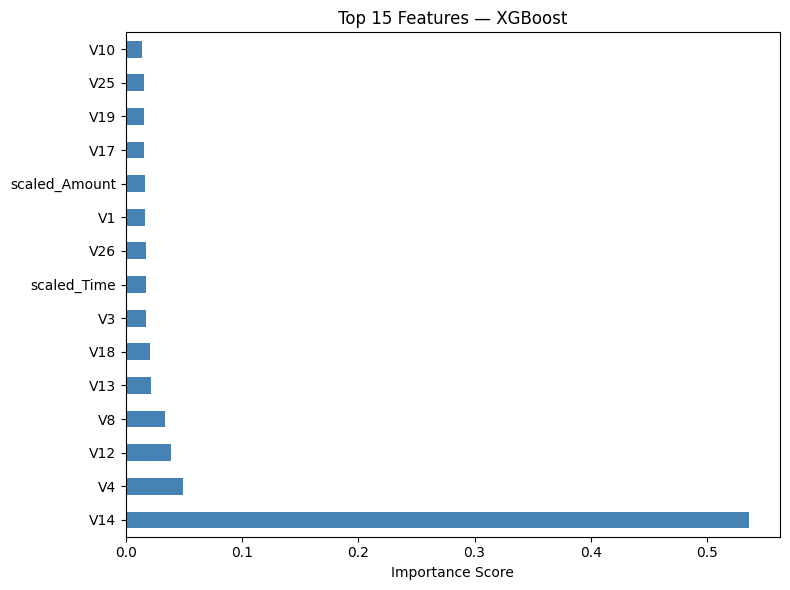

In [ ]:
feat_imp = pd.Series(xgb_model.feature_importances_, index=X_test.columns)
feat_imp.nlargest(15).plot(kind='barh', figsize=(8,6), color='steelblue')
plt.title('Top 15 Features — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Saving and Downloading the Models and Data


In [ ]:
import joblib

joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(iso_model, 'iso_model.pkl')

import numpy as np
np.save('X_test.npy', X_test.values)
np.save('y_test.npy', y_test.values)

print("saved all")


from google.colab import files
files.download('rf_model.pkl')
files.download('xgb_model.pkl')
files.download('iso_model.pkl')
files.download('X_test.npy')
files.download('y_test.npy')